# 🔩 Contagem de Parafusos — Pipeline Visual
Cada célula mostra o resultado de uma etapa do processamento.
Filtros aplicados: **área**, **solidez**, **aspecto** e **extent**.

In [6]:
# !pip install opencv-python-headless numpy matplotlib

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pathlib import Path

# ── Pasta com as imagens ───────────────────────────────────────────────
PASTA_IMAGENS = '.'          # ← troque pelo caminho da pasta
EXTENSOES     = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# ── Parâmetros ajustáveis ──────────────────────────────────────────────
BLUR_KERNEL  = (5, 5)
MORPH_KERNEL = (3, 3)
MORPH_ITER   = 2
AREA_MIN     = 200
AREA_MAX     = 50_000
MARGEM       = 30

SOLIDEZ_MIN  = 0.35
ASPECTO_MIN  = 0.10
ASPECTO_MAX  = 10.0
EXTENT_MIN   = 0.15

CLOSE_KERNEL = (9, 9)
CLOSE_ITER   = 1

USAR_WATERSHED        = True
WATERSHED_DIST_LIMIAR = 0.3

# Mostra pipeline visual etapa a etapa para cada imagem?
# True  = exibe todos os gráficos intermediários (bom pra debug de 1 imagem)
# False = mostra só o resultado final (recomendado pra processar muitas imagens)
MODO_DEBUG = False
# ──────────────────────────────────────────────────────────────────────

def mostrar(titulo, img, cmap=None):
    if not MODO_DEBUG:
        return
    plt.figure(figsize=(7, 5))
    plt.imshow(img, cmap=cmap)
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def metricas_forma(contorno):
    area      = cv2.contourArea(contorno)
    hull_area = cv2.contourArea(cv2.convexHull(contorno))
    solidez   = area / hull_area if hull_area > 0 else 0.0
    x, y, w, h = cv2.boundingRect(contorno)
    aspecto   = w / h if h > 0 else 0.0
    extent    = area / (w * h) if (w * h) > 0 else 0.0
    return dict(area=area, solidez=solidez, aspecto=aspecto, extent=extent, x=x, y=y, w=w, h=h)

def e_parafuso(m):
    if not (AREA_MIN <= m['area'] <= AREA_MAX):
        return False, f"area={m['area']:.0f}"
    if m['solidez'] < SOLIDEZ_MIN:
        return False, f"solidez={m['solidez']:.2f}"
    if not (ASPECTO_MIN <= m['aspecto'] <= ASPECTO_MAX):
        return False, f"aspecto={m['aspecto']:.2f}"
    if m['extent'] < EXTENT_MIN:
        return False, f"extent={m['extent']:.2f}"
    return True, ""

def aplicar_watershed(limpa, imagem_bgr):
    dist = cv2.distanceTransform(limpa, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, WATERSHED_DIST_LIMIAR * dist.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)
    sure_bg = cv2.dilate(limpa, np.ones((3, 3), np.uint8), iterations=3)
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    img_ws = imagem_bgr.copy()
    markers_out = cv2.watershed(img_ws, markers)
    mascara_ws = np.zeros_like(limpa)
    mascara_ws[markers_out > 1] = 255
    n_regioes = markers_out.max() - 1
    return mascara_ws, markers_out, n_regioes

def processa_imagem(caminho):
    """Processa uma imagem e retorna (n_validos, n_rejeitados, vis_final)."""
    imagem_bgr = cv2.imread(str(caminho))
    if imagem_bgr is None:
        return None, None, None

    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

    # Etapa 1 — Cinza
    cinza = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

    # Etapa 2 — Blur
    suavizada = cv2.GaussianBlur(cinza, BLUR_KERNEL, 0)

    # Etapa 3 — Binarização adaptativa
    binaria = cv2.adaptiveThreshold(
        suavizada, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        51, 4
    )

    # Etapa 4 — Morfologia
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, CLOSE_KERNEL)
    kernel_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, MORPH_KERNEL)
    fechada = cv2.morphologyEx(binaria,  cv2.MORPH_CLOSE, kernel_close, iterations=CLOSE_ITER)
    limpa   = cv2.morphologyEx(fechada,  cv2.MORPH_OPEN,  kernel_open,  iterations=MORPH_ITER)

    if MODO_DEBUG:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))
        for ax, im, t in zip(axes, [binaria, fechada, limpa],
                              ['Binarizada', 'Após Close', 'Após Open']):
            ax.imshow(im, cmap='gray'); ax.set_title(t, fontweight='bold'); ax.axis('off')
        plt.suptitle(f'Morfologia — {caminho.name}', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    # Etapa 4b — Watershed
    if USAR_WATERSHED:
        limpa, markers_out, n_ws = aplicar_watershed(limpa, imagem_bgr)
        if MODO_DEBUG:
            print(f'  Watershed: {n_ws} região(ões)')

    # Remove bordas
    h, w = limpa.shape
    limpa[:MARGEM, :]  = 0
    limpa[-MARGEM:, :] = 0
    limpa[:, :MARGEM]  = 0
    limpa[:, -MARGEM:] = 0

    # Etapa 5 — Contornos
    contornos, _ = cv2.findContours(limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    metricas = [metricas_forma(c) for c in contornos]

    # Etapa 8 — Filtros e resultado
    vis_final = imagem_rgb.copy()
    validos, rejeitados_lista = [], []

    for c, m in zip(contornos, metricas):
        ok, motivo = e_parafuso(m)
        if ok:
            validos.append((c, m))
            cv2.drawContours(vis_final, [c], -1, (0, 200, 80), 2)
            cx = m['x'] + m['w'] // 2
            cy = m['y'] + m['h'] // 2
            cv2.circle(vis_final, (cx, cy), 4, (255, 50, 50), -1)
            cv2.putText(vis_final, str(len(validos)), (cx - 8, cy - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 50, 50), 2)
        else:
            rejeitados_lista.append((c, m, motivo))
            cv2.drawContours(vis_final, [c], -1, (200, 50, 50), 1)
            cv2.putText(vis_final, motivo, (m['x'], max(m['y'] - 4, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (200, 50, 50), 1)

    return len(validos), len(rejeitados_lista), vis_final

print('✅ Imports e funções OK')


✅ Imports e funções OK


In [8]:
## 🔁 Processar todas as imagens da pasta

pasta = Path(PASTA_IMAGENS)
arquivos = sorted([p for p in pasta.iterdir() if p.suffix.lower() in EXTENSOES])

if not arquivos:
    print(f'⚠️  Nenhuma imagem encontrada em: {pasta.resolve()}')
else:
    print(f'📂 {len(arquivos)} imagem(ns) encontrada(s) em: {pasta.resolve()}')
    print()

resultados = []  # [(nome, n_validos, n_rejeitados, vis_final)]

for i, caminho in enumerate(arquivos):
    print(f'[{i+1}/{len(arquivos)}] Processando: {caminho.name} ...', end=' ')
    n_val, n_rej, vis = processa_imagem(caminho)

    if vis is None:
        print('❌ erro ao carregar')
        continue

    resultados.append((caminho.name, n_val, n_rej, vis))
    print(f'🔩 {n_val} parafuso(s)  |  ⚠️ {n_rej} rejeitado(s)')

print()
print(f'✅ Concluído — {len(resultados)}/{len(arquivos)} imagem(ns) processada(s)')


📂 5 imagem(ns) encontrada(s) em: C:\Users\f\Desktop\bootcamp\2 - Modelagem Preditiva\Desafio\Dados\Desafio-1

[1/5] Processando: img1.jpg ... 🔩 7 parafuso(s)  |  ⚠️ 0 rejeitado(s)
[2/5] Processando: img2.jpg ... 🔩 1 parafuso(s)  |  ⚠️ 0 rejeitado(s)
[3/5] Processando: img3.jpg ... 🔩 4 parafuso(s)  |  ⚠️ 4 rejeitado(s)
[4/5] Processando: img4.jpg ... 🔩 2 parafuso(s)  |  ⚠️ 0 rejeitado(s)
[5/5] Processando: img5.jpg ... 🔩 4 parafuso(s)  |  ⚠️ 0 rejeitado(s)

✅ Concluído — 5/5 imagem(ns) processada(s)


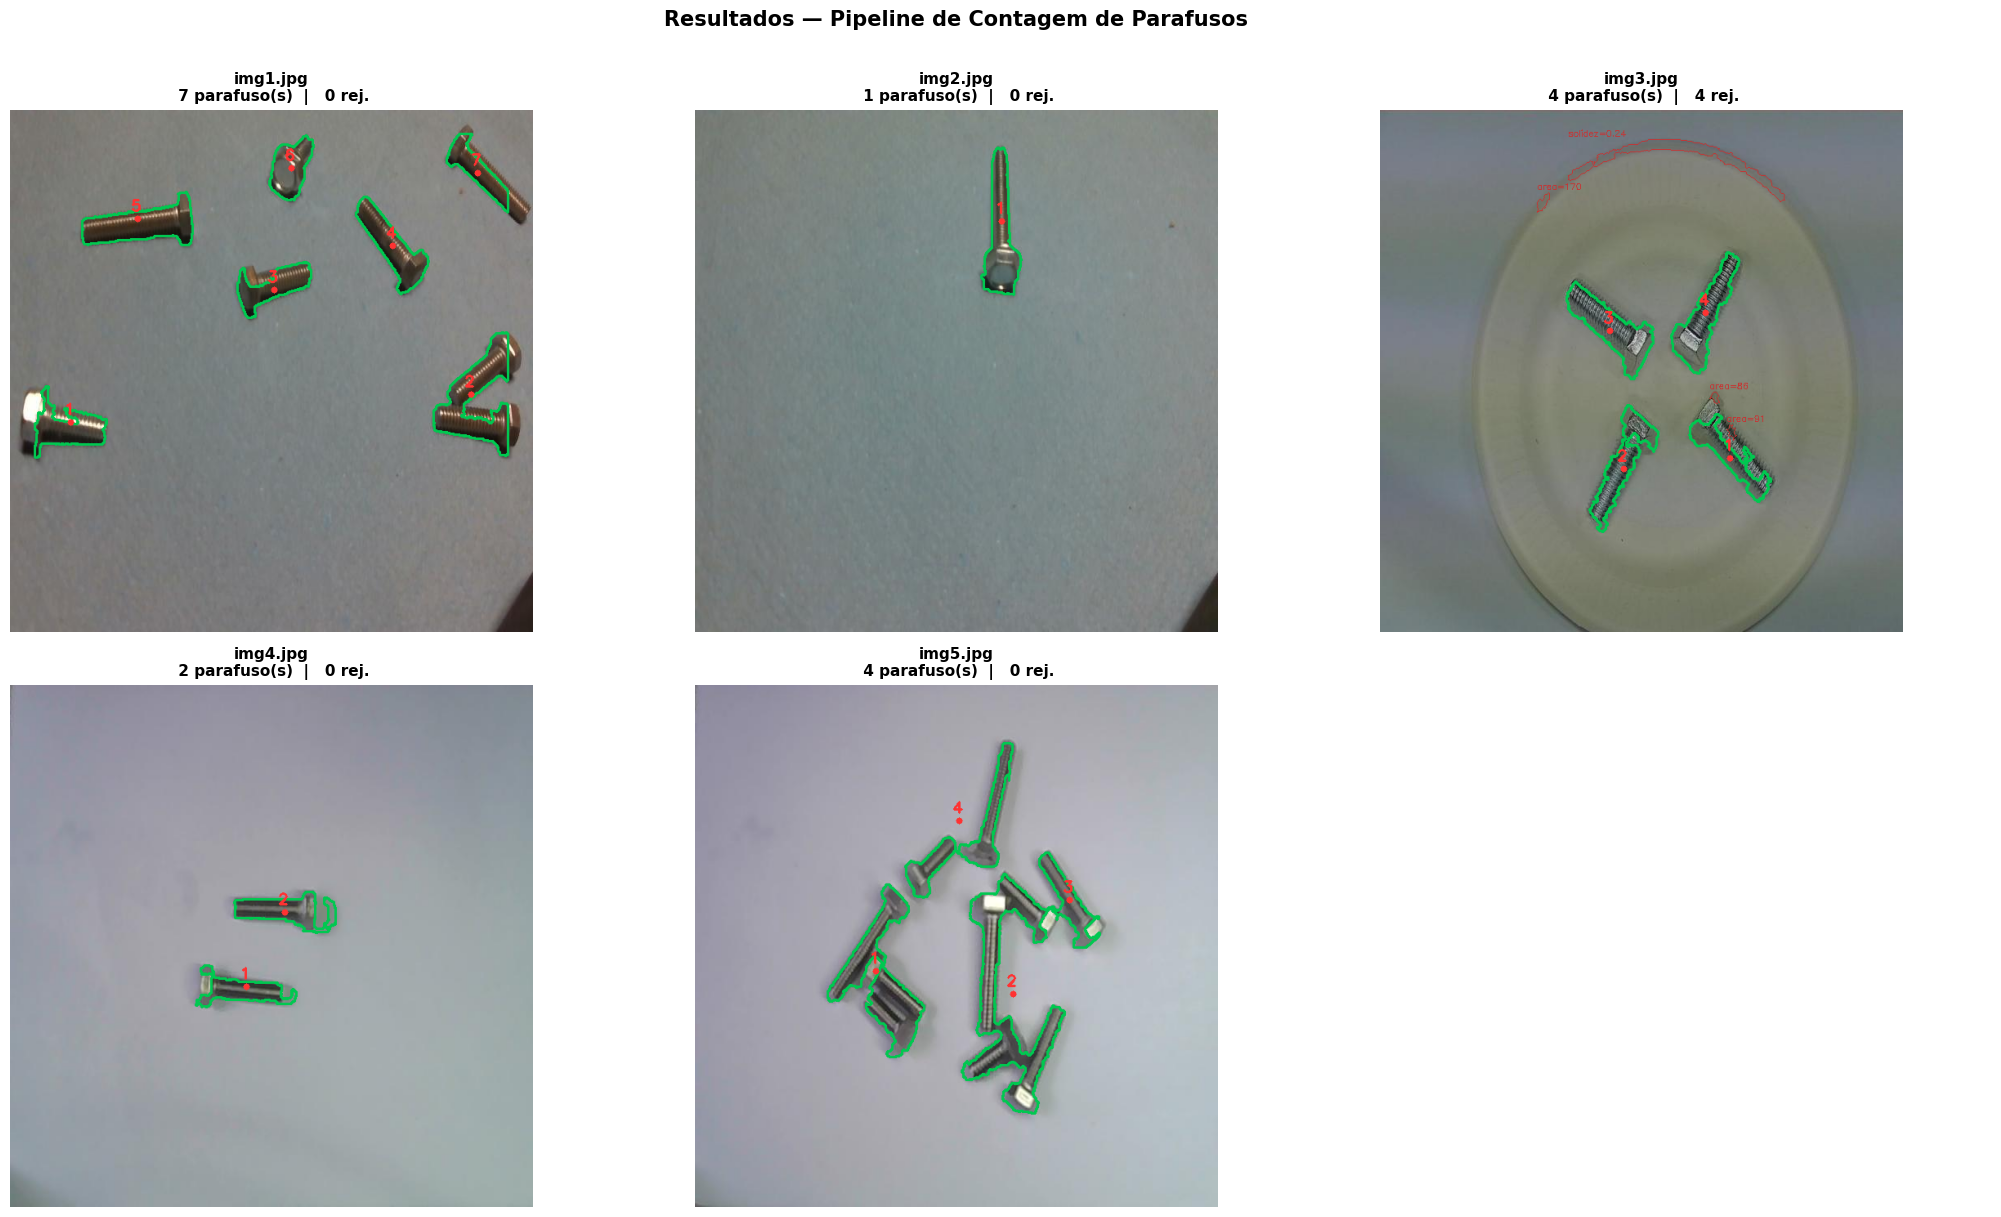

In [9]:
## 🖼️ Resultados Visuais — grade com todas as imagens

if resultados:
    n = len(resultados)
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
    axes = np.array(axes).ravel()  # garante iterável mesmo com 1 imagem

    for ax, (nome, n_val, n_rej, vis) in zip(axes, resultados):
        ax.imshow(vis)
        ax.set_title(f'{nome}\n {n_val} parafuso(s)  |   {n_rej} rej.',
                     fontsize=11, fontweight='bold')
        ax.axis('off')

    # Esconde eixos extras
    for ax in axes[len(resultados):]:
        ax.axis('off')

    plt.suptitle('Resultados — Pipeline de Contagem de Parafusos',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


In [10]:
## 📊 Tabela Resumo

if resultados:
    print(f'{'Imagem':<30} {'Parafusos':>10} {'Rejeitados':>12}')
    print('-' * 55)
    total = 0
    for nome, n_val, n_rej, _ in resultados:
        print(f'{nome:<30} {n_val:>10} {n_rej:>12}')
        total += n_val
    print('-' * 55)
    print(f'{'TOTAL':<30} {total:>10}')


Imagem                          Parafusos   Rejeitados
-------------------------------------------------------
img1.jpg                                7            0
img2.jpg                                1            0
img3.jpg                                4            4
img4.jpg                                2            0
img5.jpg                                4            0
-------------------------------------------------------
TOTAL                                  18
